In [1]:
#For install LangGraph
!pip install langgraph -q

In [2]:
#Initialize TypeDict
from typing import TypedDict  #TypeDict -> There is a pre difined structure for key-values then we can only add values according to that defined key order

In [3]:
class AgentState(TypedDict):
    name: str  #name kiyala key ekak pre-defined thinava ekata string values pass krnn puluvan me dict ekata
    age : int
    msg : str

In [15]:
def hello(state : AgentState) -> AgentState:
  state['msg']= f"Hello {state['name']}, Your age is {state['age']}"
  return state

# mekedi wenne AgentState kiyana class eke type input ekak(TypeDict type eke) dunnama eka modify karala newatha ema input ekatama sabve karala ema input ekma output ekak vdht return karanava

In [16]:
#For create a graph
from langgraph.graph import StateGraph, START, END

In [17]:
workflow= StateGraph(AgentState)  #set a onbeject of a state graph for define the graph, Agentge data thiyenna oni vidihath denva

workflow.add_node("hello",hello)

workflow.add_edge(START,"hello") # STRAT -> hello
workflow.add_edge("hello",END)   # hello -> END

app= workflow.compile()  #finally want to compile the workflow

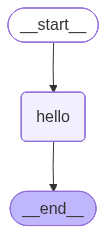

In [18]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [19]:
# Use the created graph
result= app.invoke({"name":"Udaya", "age":24})
print(result)

{'name': 'Udaya', 'age': 24, 'msg': 'Hello Udaya, Your age is 24'}


# For Sequential Graph

In [22]:
# Fore Node1
def hello_1(state : AgentState) -> AgentState:
  state['msg']= f"Hello {state['name']}!"
  return state

# For Node2
def hello_2(state : AgentState) -> AgentState:
  state['msg']= f"{state['msg']}, Your age is {state['age']}"
  return state

In [24]:
# Define Sequential Workflow

workflow= StateGraph(AgentState)

workflow.add_node("hello_1",hello_1)
workflow.add_node("hello_2",hello_2)

workflow.add_edge(START,"hello_1") # STRAT -> hello1
workflow.add_edge("hello_1","hello_2") # hello1 -> hello2
workflow.add_edge("hello_2",END)   # hello2 -> END

app= workflow.compile()

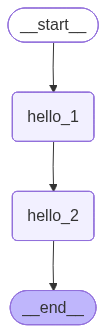

In [25]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [26]:
# Use the created graph
result= app.invoke({"name":"Udaya", "age":24})
print(result)

{'name': 'Udaya', 'age': 24, 'msg': 'Hello Udaya!, Your age is 24'}


#For Conditional Graph

In [28]:
# Create Data Type
class AgentState(TypedDict):
    x : int
    y : int
    opn : str
    result : int

In [32]:
# For Addition (Node1)
def addition(state : AgentState) -> AgentState:
  state['result']= state['x'] + state['y']
  return state


# For Substraction (Node2)
def substraction(state : AgentState) -> AgentState:
  state['result']= state['x'] - state['y']
  return state

# For Division (Node3)
def division(state : AgentState) -> AgentState:
  state['result']= state['x'] / state['y']
  return state


# For Mpy (Node4)
def mpy(state : AgentState) -> AgentState:
  state['result']= state['x'] * state['y']
  return state

In [39]:
# For Decision Making Node

def decision_node(state:AgentState) -> AgentState:
  if state['opn'] == 'add':
    return 'addition'  # addition kiyna edge ekata yanawa kiyana eka
  elif state['opn'] == 'sub':
    return 'subtraction'
  elif state['opn'] == 'div':
    return 'division'
  elif state['opn'] == 'mul':
    return 'multify'

In [42]:
# Define Conditional Workflow

workflow= StateGraph(AgentState)

workflow.add_node("add",addition)
workflow.add_node("sub",substraction)
workflow.add_node("div",division)
workflow.add_node("mpy",mpy)

# For the decision making node
workflow.add_node("decision", lambda state:state) #me node eken state ekak return nokara edje ekak return krna nisai lambda func use kle

workflow.add_edge(START,"decision")
workflow.add_conditional_edges(
    "decision",  # Decision node eke Name eka
    decision_node,  # eke adala function eka
    {
        "addition":"add",  #addtion kiyana edge eken giyama add kiyna node ekata ynna oni
        "subtraction":"sub",
        "division":"div",
        "multify":"mpy"
    }
)

workflow.add_edge("add",END)
workflow.add_edge("sub",END)
workflow.add_edge("div",END)
workflow.add_edge("mpy",END)

app= workflow.compile()

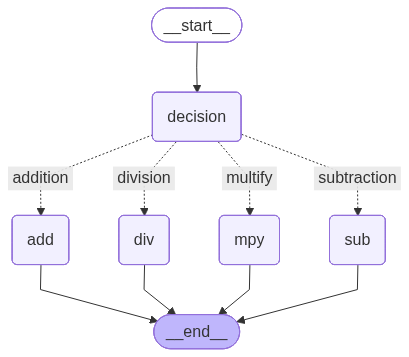

In [43]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [45]:
rslt= app.invoke({"x":80, "y":4, "opn":"sub"})
print(rslt)

{'x': 80, 'y': 4, 'opn': 'sub', 'result': 76}
